<a href="https://colab.research.google.com/github/queensss/Algorithms/blob/main/4th_feature_selection_1st_Final_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [129]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



In [130]:

df = pd.read_excel("/content/bdhs2022_final_analysis_dataset_new - Copy.xlsx")

In [131]:
df.head()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
0,32.0,156207,1.0,111.0,1,3,2.0,1,63.0,2.0,...,1,1,1,1,1,0,0,4,0,0.08
1,18.0,141953,2.0,3.0,1,2,2.0,0,56.0,2.0,...,0,2,1,1,0,0,0,4,0,-1.61
2,14.0,141953,2.0,23.0,1,3,1.0,0,NaN,1.0,...,1,2,1,1,0,1,1,5,0,-1.29
3,NaN,141953,2.0,34.0,1,3,3.0,0,46.0,3.0,...,1,2,1,1,0,0,1,4,1,-2.27
4,5.0,141953,2.0,146.0,1,2,2.0,0,24.0,2.0,...,1,2,1,1,1,1,1,5,0,-0.31


In [132]:
df.tail()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
2486,6.0,699635,675.0,31.0,1,1,4.0,0,77.0,4.0,...,1,1,0,1,0,0,0,2,0,-1.92
2487,23.0,699635,675.0,41.0,2,0,2.0,0,34.0,3.0,...,0,0,0,1,0,0,1,2,1,-3.10
2488,2.0,699635,675.0,70.0,1,1,3.0,0,25.0,3.0,...,1,2,0,1,0,0,0,1,0,-0.47
2489,28.0,699635,675.0,70.0,2,1,2.0,0,41.0,3.0,...,1,0,0,1,0,0,0,1,0,-1.79
2490,12.0,699635,675.0,108.0,1,2,2.0,0,34.0,2.0,...,0,0,0,1,0,0,0,2,0,-1.00


In [133]:
df.shape

(2491, 27)

In [134]:
print(df.columns.tolist())

['age_months', 'sample_weight', 'cluster_id', 'hh_id', 'child_line', 'mother_edu', 'birth_order', 'mother_occ', 'birth_interval_months', 'children_ever_born', 'father_edu', 'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean', 'skilled_birth', 'toilet_improved', 'delivery_place_3cat', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'small_at_birth', 'wants_more_children', 'wealth_index_clean', 'stunted', 'haz']


In [135]:
df.columns.tolist()

['age_months',
 'sample_weight',
 'cluster_id',
 'hh_id',
 'child_line',
 'mother_edu',
 'birth_order',
 'mother_occ',
 'birth_interval_months',
 'children_ever_born',
 'father_edu',
 'division',
 'mother_age',
 'wt',
 'mother_bmi',
 'father_occ_clean',
 'skilled_birth',
 'toilet_improved',
 'delivery_place_3cat',
 'has_tv_clean',
 'has_electricity_clean',
 'reads_newspaper_clean',
 'small_at_birth',
 'wants_more_children',
 'wealth_index_clean',
 'stunted',
 'haz']

# missing value check  
# heatmap

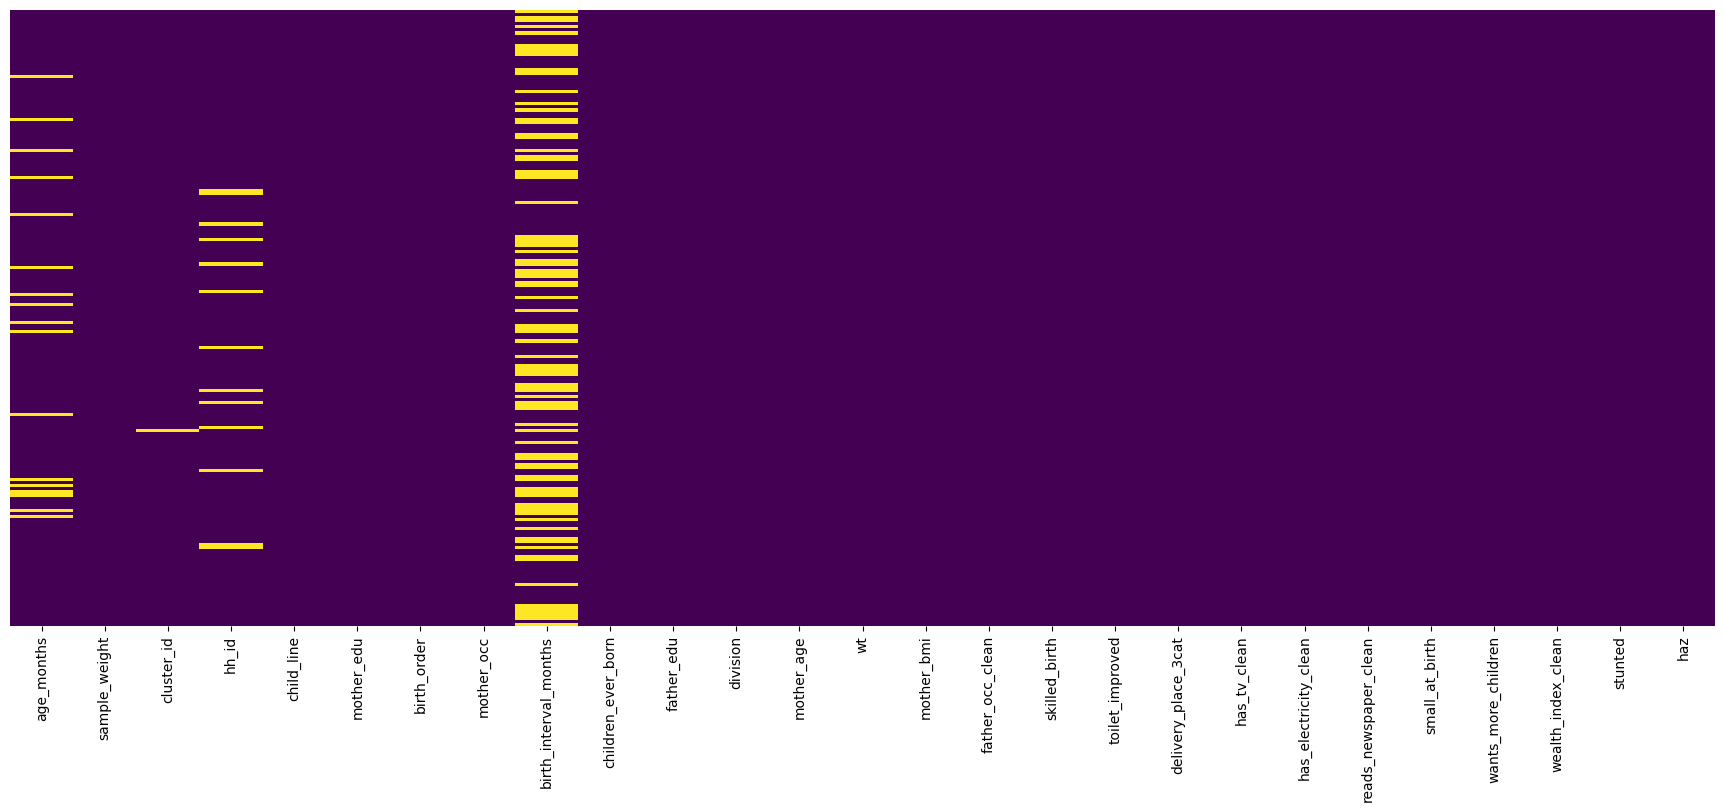

In [136]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()

# Bar chart

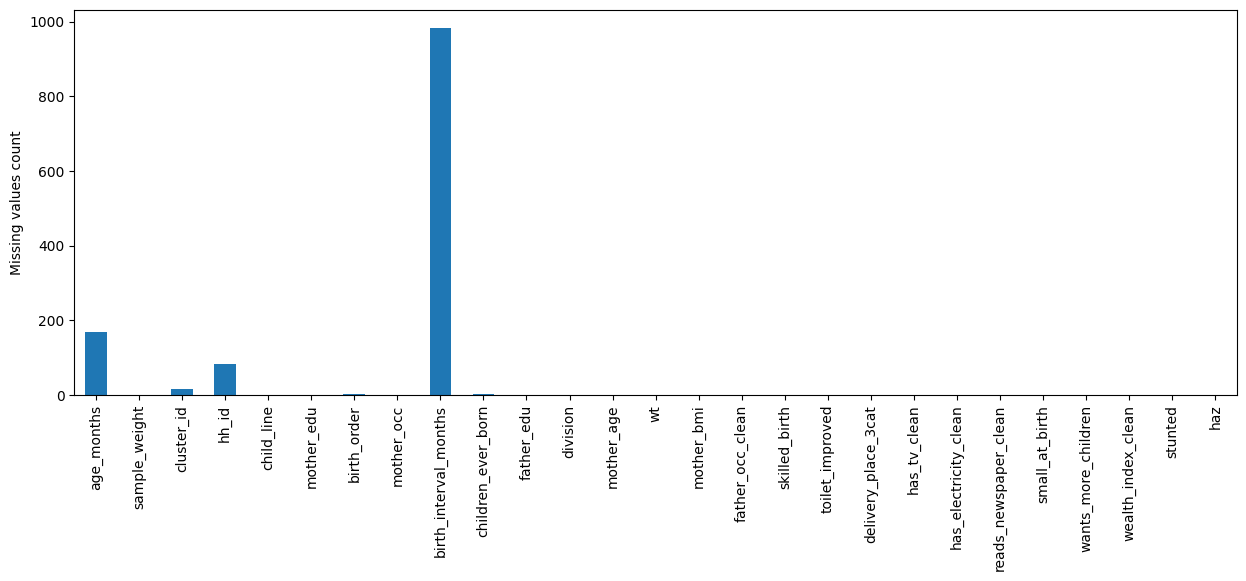

In [137]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [138]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                 Variable  Missing_Percent
8   birth_interval_months        39.462063
0              age_months         6.744279
3                   hh_id         3.291851
2              cluster_id         0.602168
9      children_ever_born         0.080289
6             birth_order         0.080289
14             mother_bmi         0.040145
5              mother_edu         0.000000
4              child_line         0.000000
7              mother_occ         0.000000
1           sample_weight         0.000000
10             father_edu         0.000000
11               division         0.000000
12             mother_age         0.000000
13                     wt         0.000000
15       father_occ_clean         0.000000
16          skilled_birth         0.000000
17        toilet_improved         0.000000
18    delivery_place_3cat         0.000000
19           has_tv_clean         0.000000
20  has_electricity_clean         0.000000
21  reads_newspaper_clean         0.000000
22         

In [139]:
df = df.drop(columns=['hh_id', 'cluster_id'])

In [140]:
df.shape

(2491, 25)

In [141]:
missing_percent = df.isnull().mean() * 100

In [142]:
threshold = 30


In [143]:
df = df.loc[:, missing_percent <= threshold]


In [144]:
cols_to_drop = missing_percent[missing_percent > 30].index
print(cols_to_drop)


Index(['birth_interval_months'], dtype='object')


In [145]:
df.shape

(2491, 24)

In [146]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['age_months', 'sample_weight', 'child_line', 'mother_edu',
       'birth_order', 'mother_occ', 'children_ever_born', 'father_edu',
       'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean',
       'skilled_birth', 'toilet_improved', 'delivery_place_3cat',
       'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean',
       'small_at_birth', 'wants_more_children', 'wealth_index_clean',
       'stunted', 'haz'],
      dtype='object')

In [147]:
id_vars = ['cluster_id', 'hh_id', 'child_line']


In [148]:
numeric_vars = [
   'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]


In [149]:
all_df_cols = df.columns.tolist()

# Filter id_vars to only include columns that are still in df
current_id_vars = [col for col in id_vars if col in all_df_cols]

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

categorical_vars = list(
    set(all_df_cols) - set(current_id_vars) - set(current_numeric_vars)
)



In [150]:
print("ID variables:\n", id_vars)
print("\nNumeric variables:\n", numeric_vars)
print("\nCategorical variables:\n", categorical_vars)


ID variables:
 ['cluster_id', 'hh_id', 'child_line']

Numeric variables:
 ['age_months', 'children_ever_born', 'mother_age', 'birth_order', 'mother_bmi']

Categorical variables:
 ['has_electricity_clean', 'father_edu', 'wealth_index_clean', 'delivery_place_3cat', 'wt', 'mother_edu', 'has_tv_clean', 'division', 'haz', 'sample_weight', 'small_at_birth', 'stunted', 'toilet_improved', 'mother_occ', 'reads_newspaper_clean', 'skilled_birth', 'father_occ_clean', 'wants_more_children']


# Normality check

In [151]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.062,0.0,Non-normal
1,children_ever_born,1.200,0.0,Non-normal
2,mother_age,0.543,0.0,Non-normal
3,birth_order,1.207,0.0,Non-normal
4,mother_bmi,0.687,0.0,Non-normal


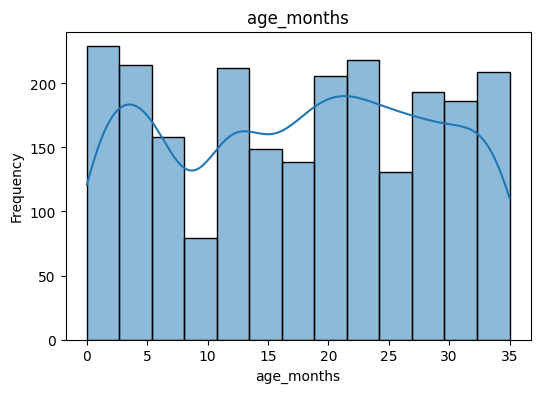

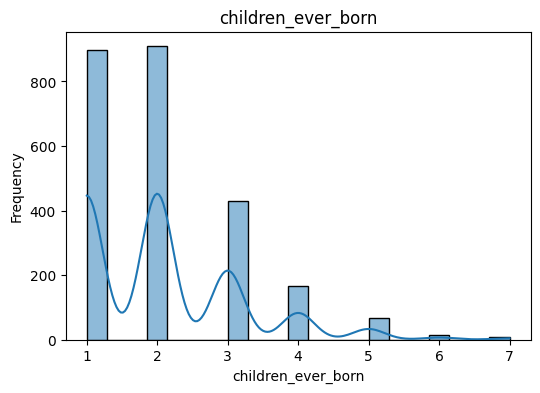

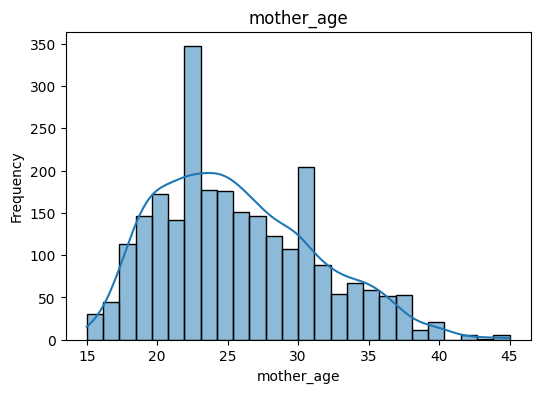

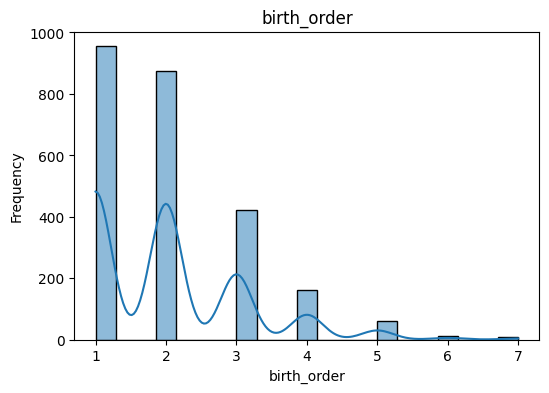

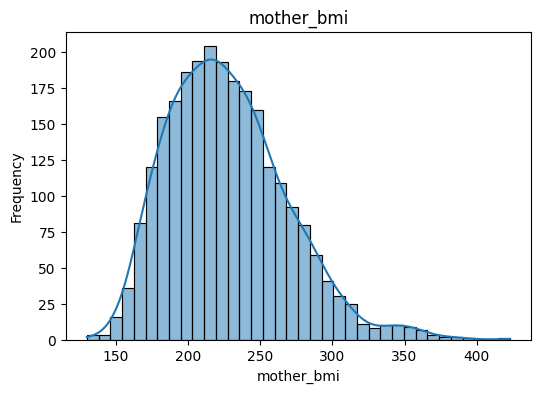

In [152]:


# List of numeric variables (non-normal)
numeric_cols = [
      'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# MICE PMM

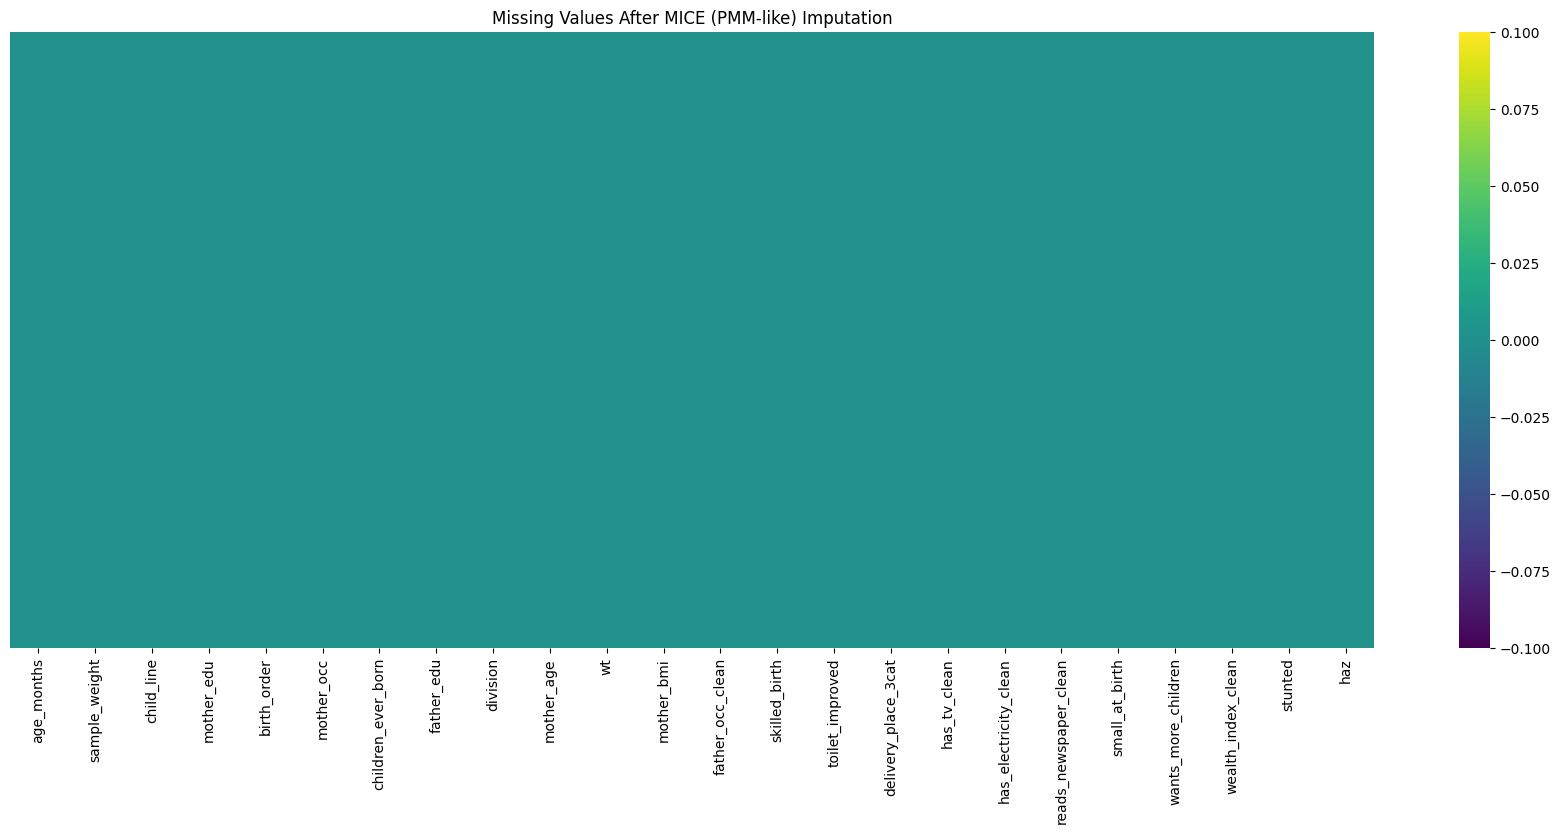

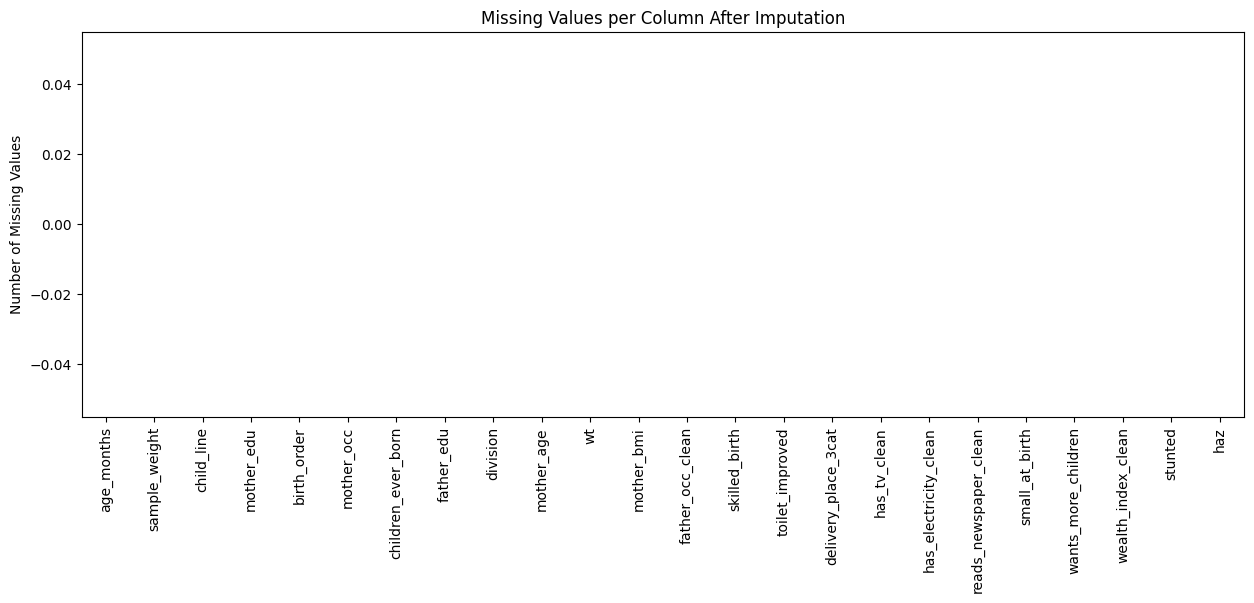

Total missing values after imputation: 0


In [153]:

# =============================
# Imports (Colab compatible)
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# =============================
# Load data (example)
# =============================
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# =============================
# Define NON-NORMAL variables
# =============================
non_normal_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',]

# =============================
# MICE / PMM-like Imputation
# =============================
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    sample_posterior=True
)

df[non_normal_vars] = mice_imputer.fit_transform(df[non_normal_vars])

# =============================
# Check missing values
# =============================
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title("Missing Values After MICE (PMM-like) Imputation")
plt.show()

df.isnull().sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(15, 5)
)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column After Imputation")
plt.show()

print("Total missing values after imputation:", df.isnull().sum().sum())

In [154]:
import pandas as pd

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)



                 Variable  Missing_Percent
0              age_months              0.0
1           sample_weight              0.0
2              child_line              0.0
3              mother_edu              0.0
4             birth_order              0.0
5              mother_occ              0.0
6      children_ever_born              0.0
7              father_edu              0.0
8                division              0.0
9              mother_age              0.0
10                     wt              0.0
11             mother_bmi              0.0
12       father_occ_clean              0.0
13          skilled_birth              0.0
14        toilet_improved              0.0
15    delivery_place_3cat              0.0
16           has_tv_clean              0.0
17  has_electricity_clean              0.0
18  reads_newspaper_clean              0.0
19         small_at_birth              0.0
20    wants_more_children              0.0
21     wealth_index_clean              0.0
22         

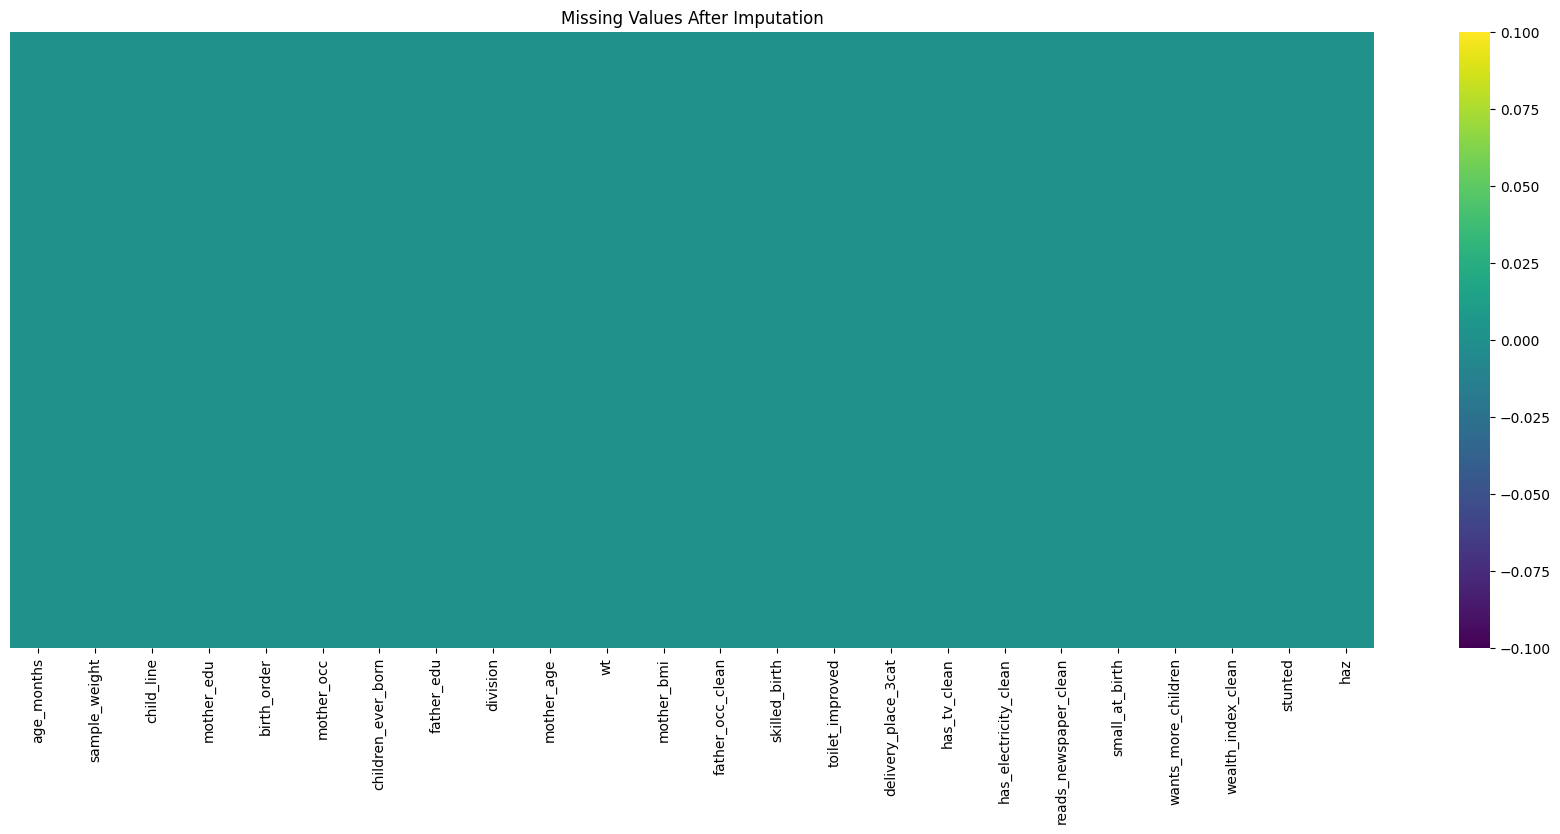

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()


aftre missing value handled we have 24 variable

In [156]:
df.shape

(2491, 24)

In [157]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,2491.0,1.758312e+01,10.654874,-5.135347,7.000000,18.000000,2.600000e+01,4.583307e+01
sample_weight,2491.0,1.017775e+06,512971.185567,91325.000000,670684.000000,956806.000000,1.333414e+06,3.891736e+06
child_line,2491.0,1.045363e+00,0.211965,1.000000,1.000000,1.000000,1.000000e+00,3.000000e+00
mother_edu,2491.0,1.867122e+00,0.785158,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
birth_order,2491.0,2.017559e+00,1.078969,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
mother_occ,2491.0,2.079486e-01,0.405921,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
children_ever_born,2491.0,2.063017e+00,1.094907,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
father_edu,2491.0,1.615415e+00,0.970564,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
division,2491.0,3.586511e+00,1.925741,1.000000,2.000000,3.000000,5.000000e+00,7.000000e+00
mother_age,2491.0,2.567041e+01,5.577652,15.000000,21.000000,25.000000,2.900000e+01,4.500000e+01


In [158]:
# Ensure lists match existing columns
numeric_vars = [col for col in numeric_vars if col in df.columns]
categorical_vars = [col for col in categorical_vars if col in df.columns]

# Convert numeric-coded categorical variables to 'category' type
for col in categorical_vars:
    df[col] = df[col].astype('category')

# Now describe
print(df[numeric_vars].describe())
print(df[categorical_vars].describe())


        age_months  children_ever_born   mother_age  birth_order   mother_bmi
count  2491.000000         2491.000000  2491.000000  2491.000000  2491.000000
mean     17.583119            2.063017    25.670413     2.017559   227.291901
std      10.654874            1.094907     5.577652     1.078969    41.025877
min      -5.135347            1.000000    15.000000     1.000000   130.000000
25%       7.000000            1.000000    21.000000     1.000000   196.500000
50%      18.000000            2.000000    25.000000     2.000000   223.000000
75%      26.000000            3.000000    29.000000     3.000000   251.850000
max      45.833074            7.000000    45.000000     7.000000   422.700000
        has_electricity_clean  father_edu  wealth_index_clean  \
count                    2491        2491                2491   
unique                      2           4                   5   
top                         1           2                   1   
freq                     2459         

### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot and countplot to understand  the distribution




### Correlation heatmap for Numerical variable.

#boxplot to identify the outlier

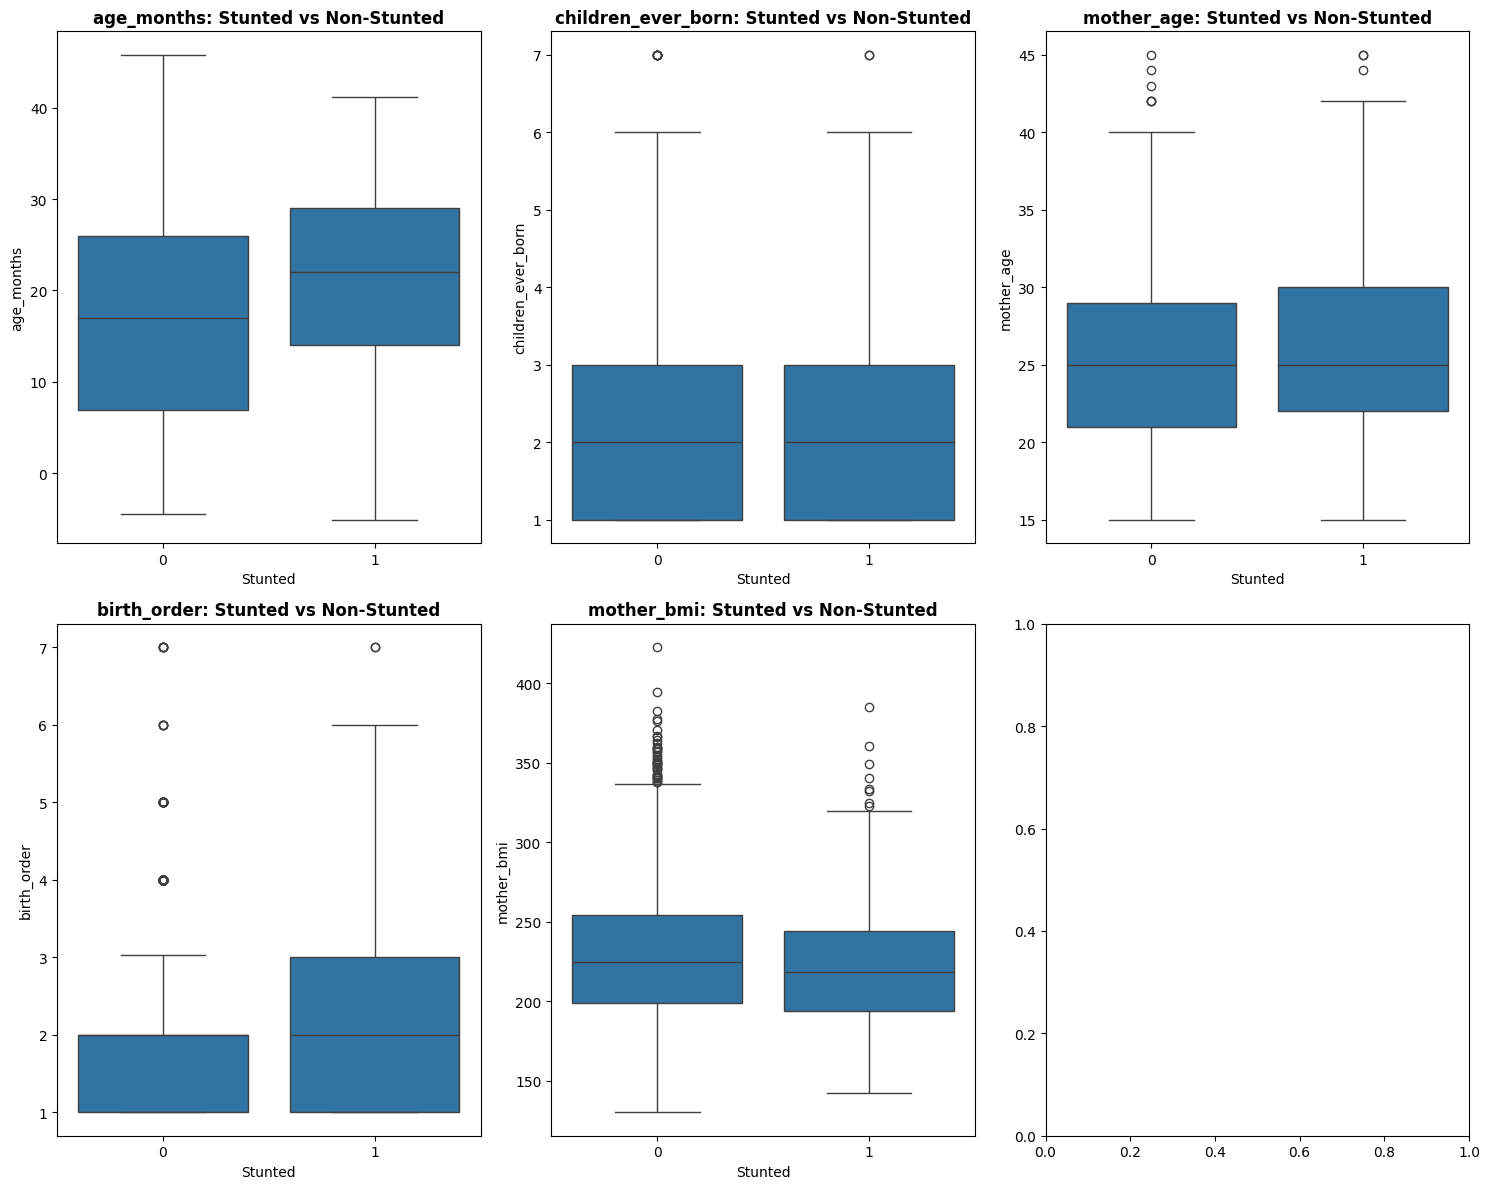

In [159]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1A. Stunting vs Key Continuous Variables
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.ravel()

key_vars = [ 'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
   ]

for i, var in enumerate(key_vars):
    sns.boxplot(data=df, x='stunted', y=var, ax=axes[i])
    axes[i].set_title(f'{var}: Stunted vs Non-Stunted', fontweight='bold')
    axes[i].set_xlabel('Stunted')

plt.tight_layout()
plt.show()

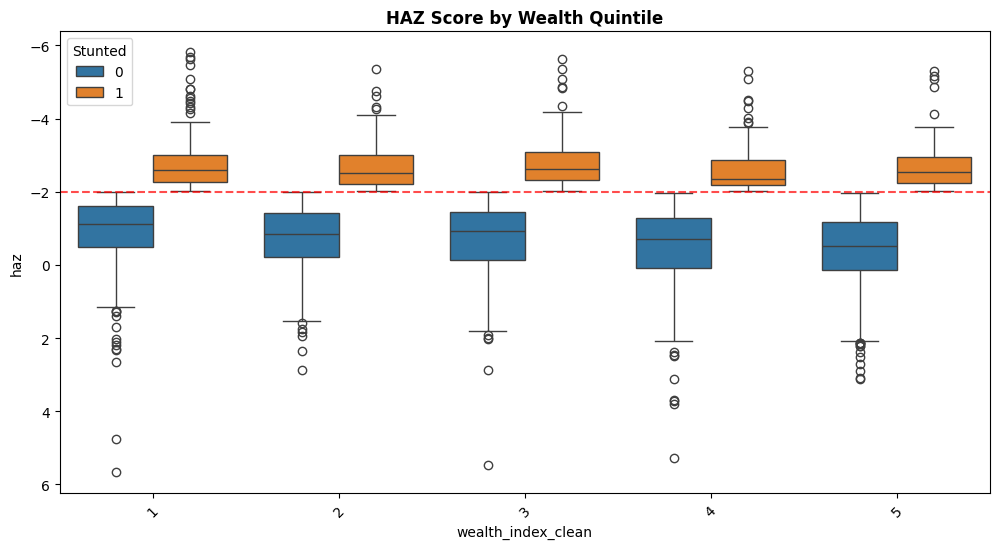

In [160]:
# 1B. Wealth Quintiles - HAZ Distribution
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='wealth_index_clean', y='haz', hue='stunted')
plt.title('HAZ Score by Wealth Quintile', fontweight='bold')
plt.xticks(rotation=45)
plt.axhline(y=-2, color='red', linestyle='--', alpha=0.7)
plt.legend(title='Stunted')
plt.show()

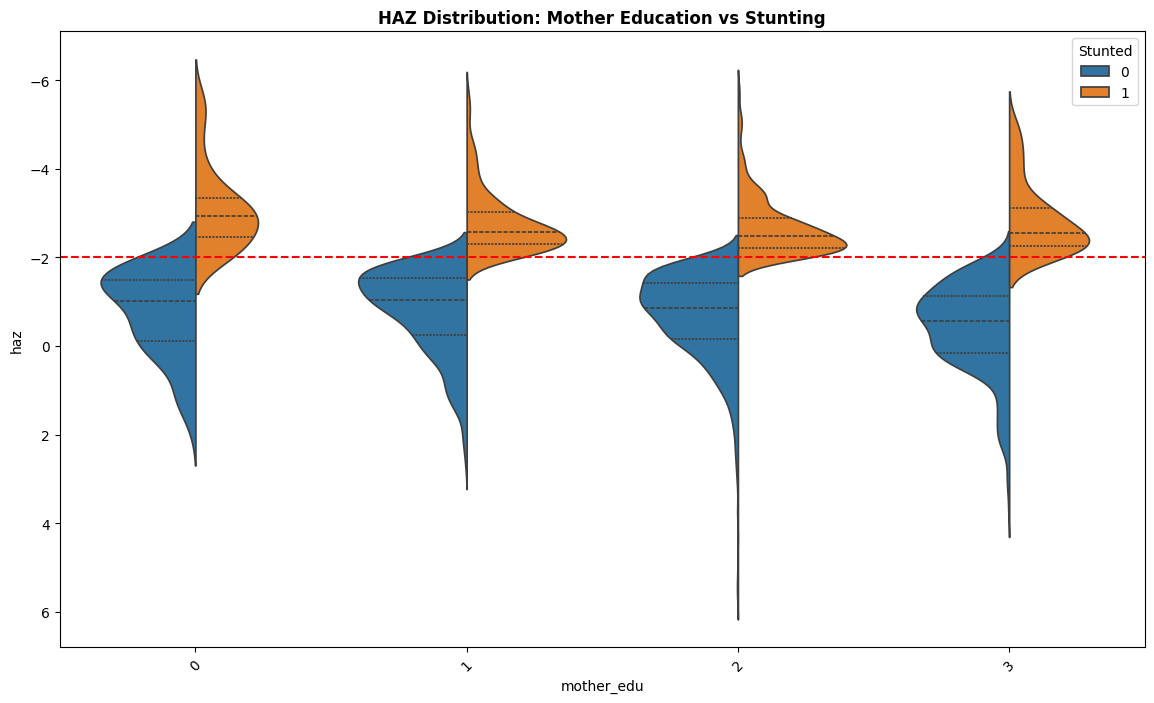

In [161]:
# Mother Education vs HAZ by Stunting
plt.figure(figsize=(14, 8))
sns.violinplot(data=df, x='mother_edu', y='haz', hue='stunted', split=True, inner='quart')
plt.title('HAZ Distribution: Mother Education vs Stunting', fontweight='bold')
plt.xticks(rotation=45)
plt.axhline(y=-2, color='red', linestyle='--')
plt.legend(title='Stunted')
plt.show()

In [162]:
pip install joypy

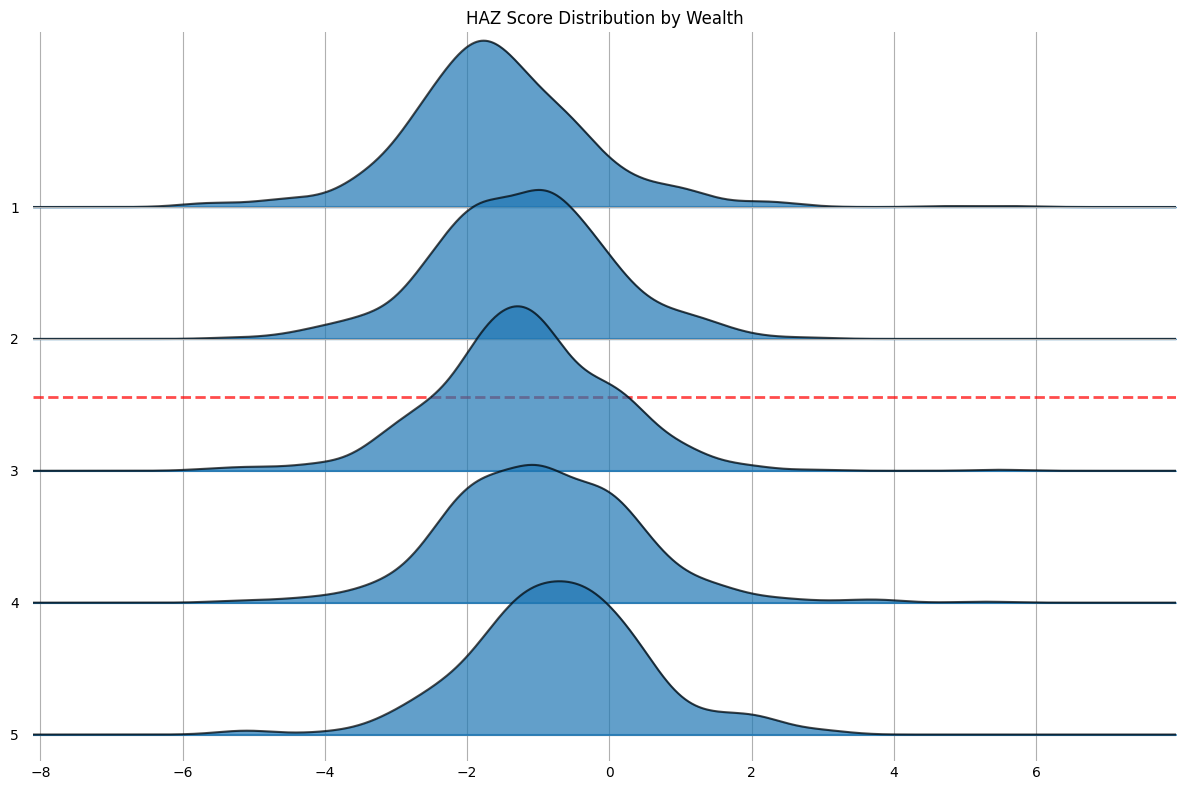

In [163]:
# Install: pip install joypy
import joypy

# 3A. HAZ by Wealth (Ridgeline)
joypy.joyplot(df, column=['haz'], by='wealth_index_clean',
              figsize=(12, 8), title='HAZ Score Distribution by Wealth',
              grid=True, fill=True, alpha=0.7)
plt.axhline(y=-2, color='red', linestyle='--', alpha=0.7, linewidth=2)
plt.show()

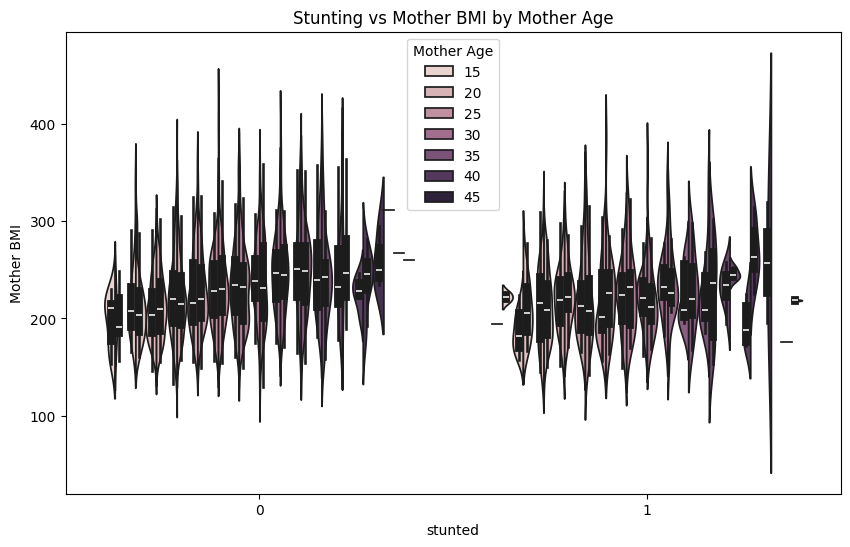

In [164]:
# 1B. Stunting vs Mother BMI
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='stunted', y='mother_bmi', hue='mother_age', split=True)
plt.title('Stunting vs Mother BMI by Mother Age')
plt.ylabel('Mother BMI')
plt.legend(title='Mother Age')
plt.show()

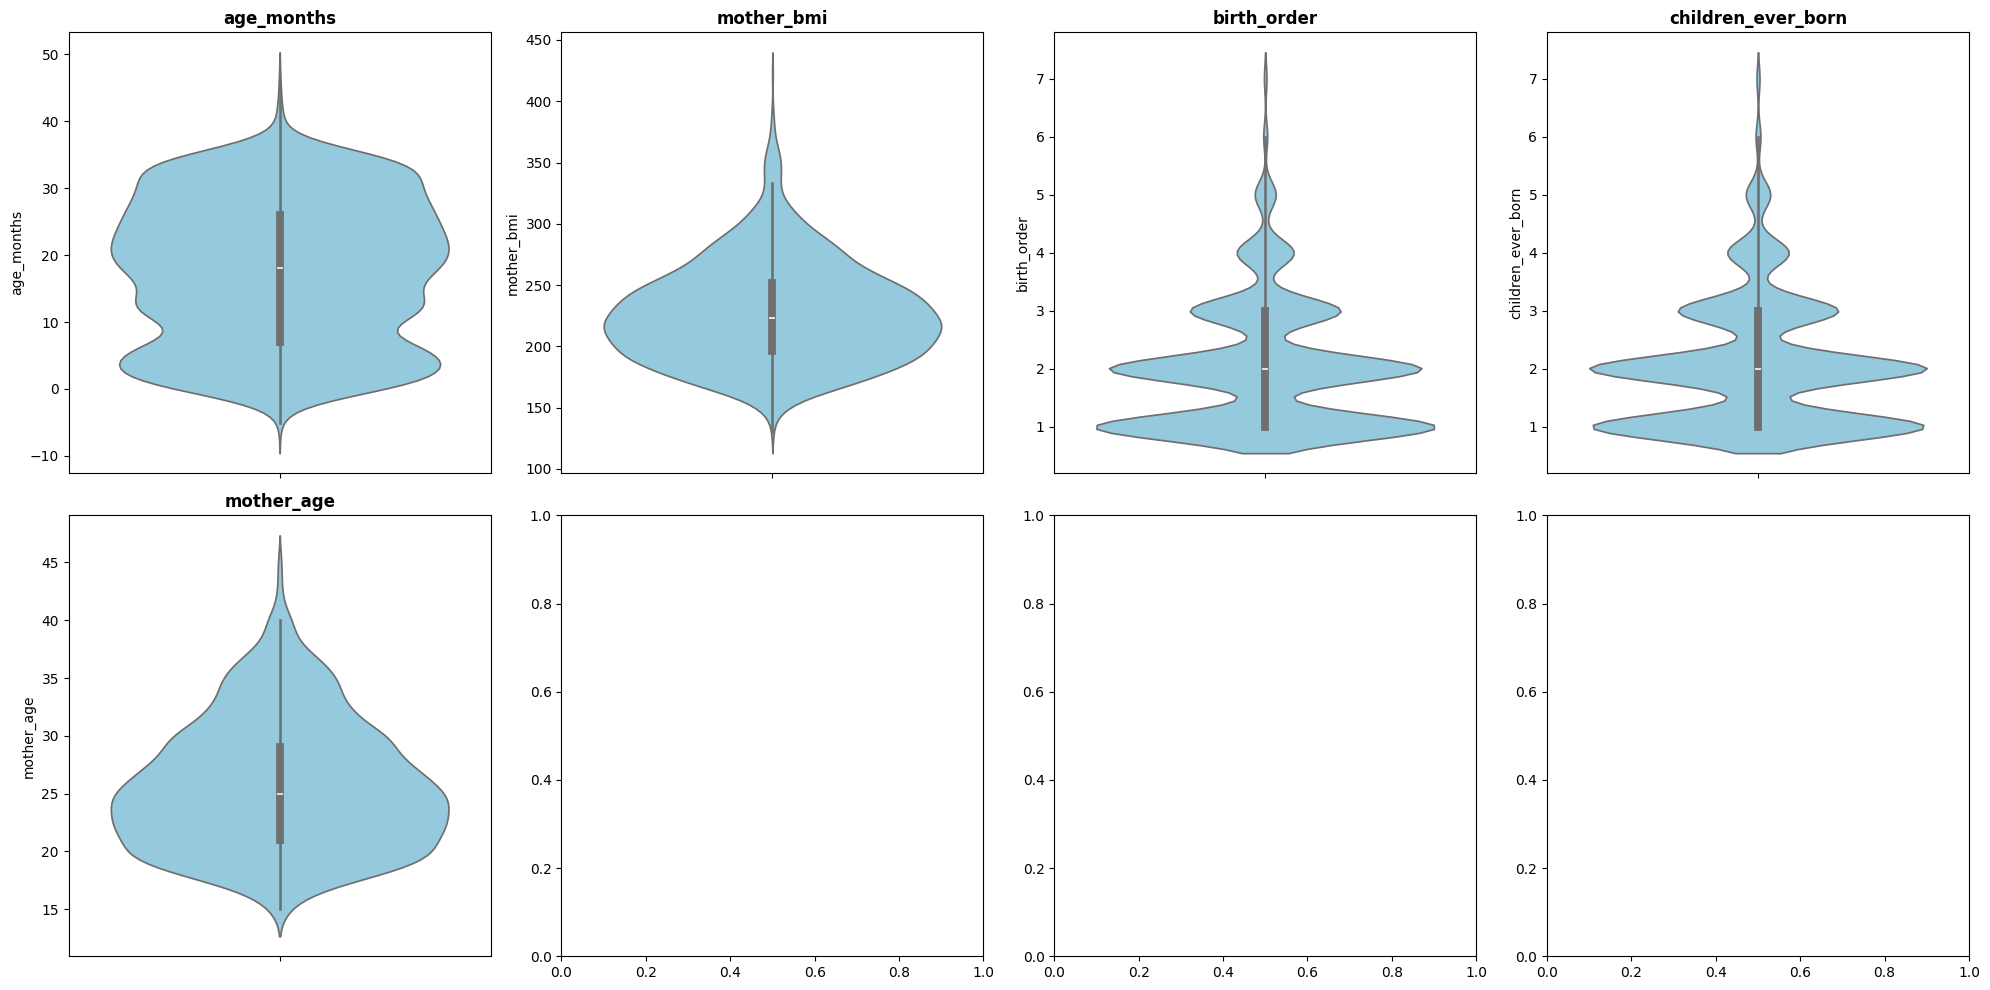

In [165]:
# Select numerical columns
num_cols = ['age_months',  'mother_bmi',   'birth_order',
            'children_ever_born', 'mother_age']

df_num = df[num_cols].dropna()

# Violin plot grid
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.violinplot(y=df_num[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [166]:
def iqr_outliers(df, columns):
    outlier_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lb = Q1 - 1.5 * IQR
        ub = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lb) | (df[col] > ub)]

        outlier_info[col] = {
            "lower_bound": lb,
            "upper_bound": ub,
            "num_outliers": outliers.shape[0]
        }

    return outlier_info


In [167]:
columns_to_check = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

outlier_results = iqr_outliers(df, columns_to_check)


In [168]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -21.5
Upper bound: 54.5
Number of outliers: 0

Column: children_ever_born
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 8

Column: mother_age
Lower bound: 9.0
Upper bound: 41.0
Number of outliers: 11

Column: birth_order
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 7

Column: mother_bmi
Lower bound: 113.47499999999997
Upper bound: 334.87500000000006
Number of outliers: 44


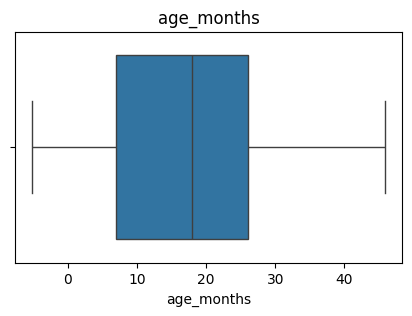

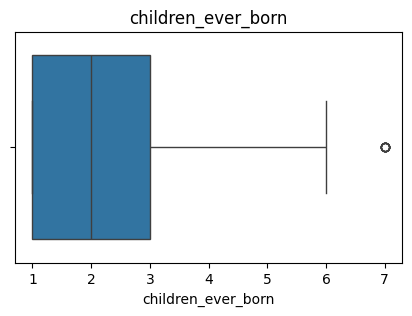

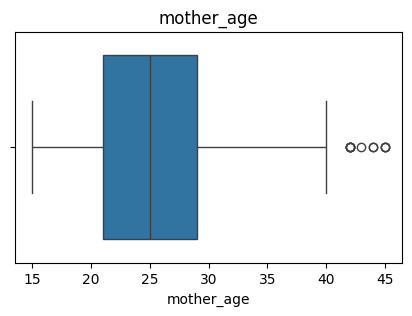

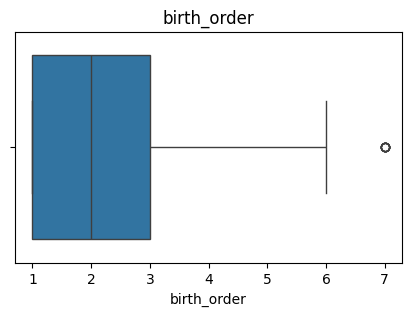

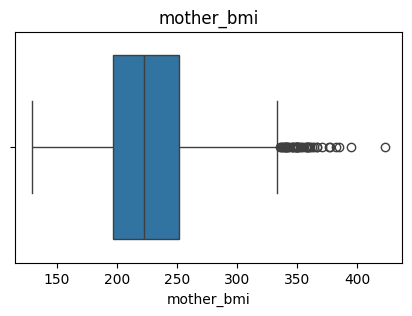

In [169]:
for col in columns_to_check:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


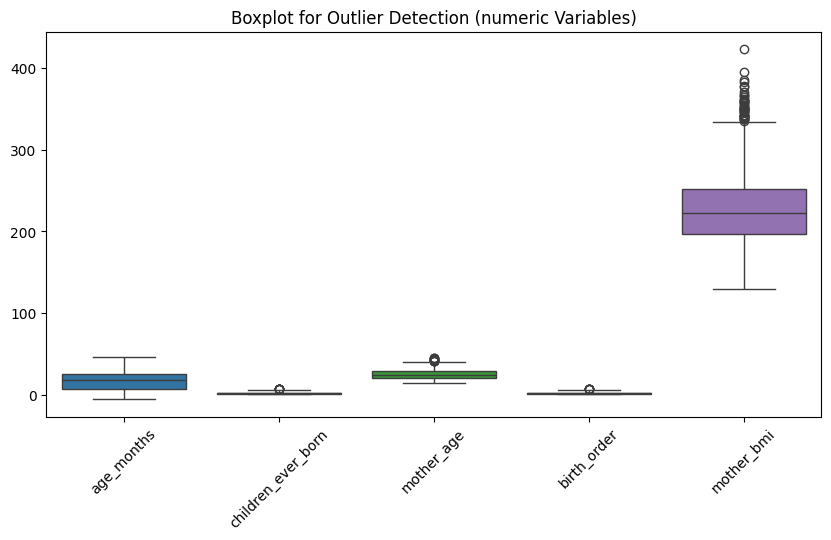

In [170]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for Outlier Detection (numeric Variables)")
plt.show()



# whisker use to handle outlier

In [171]:
import pandas as pd
import numpy as np

# 1. Define a helper to calculate bounds (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
def get_winsorize_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

cols = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi']

for col in cols:
    # Calculate bounds
    lw, uw = get_winsorize_bounds(df[col])

    # Clip values between lw and uw
    df[col] = df[col].clip(lower=lw, upper=uw)

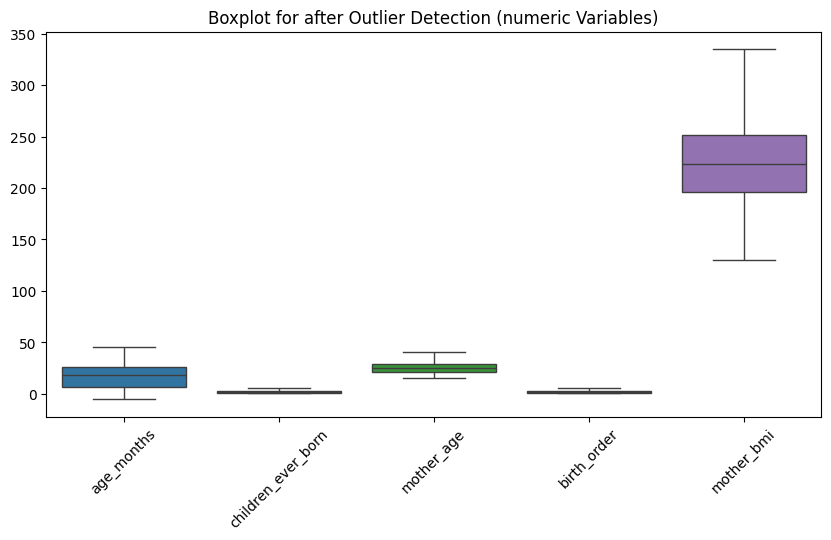

In [172]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[columns_to_check])
plt.xticks(rotation=45)
plt.title("Boxplot for after Outlier Detection (numeric Variables)")
plt.show()

### Scaling numerical variables

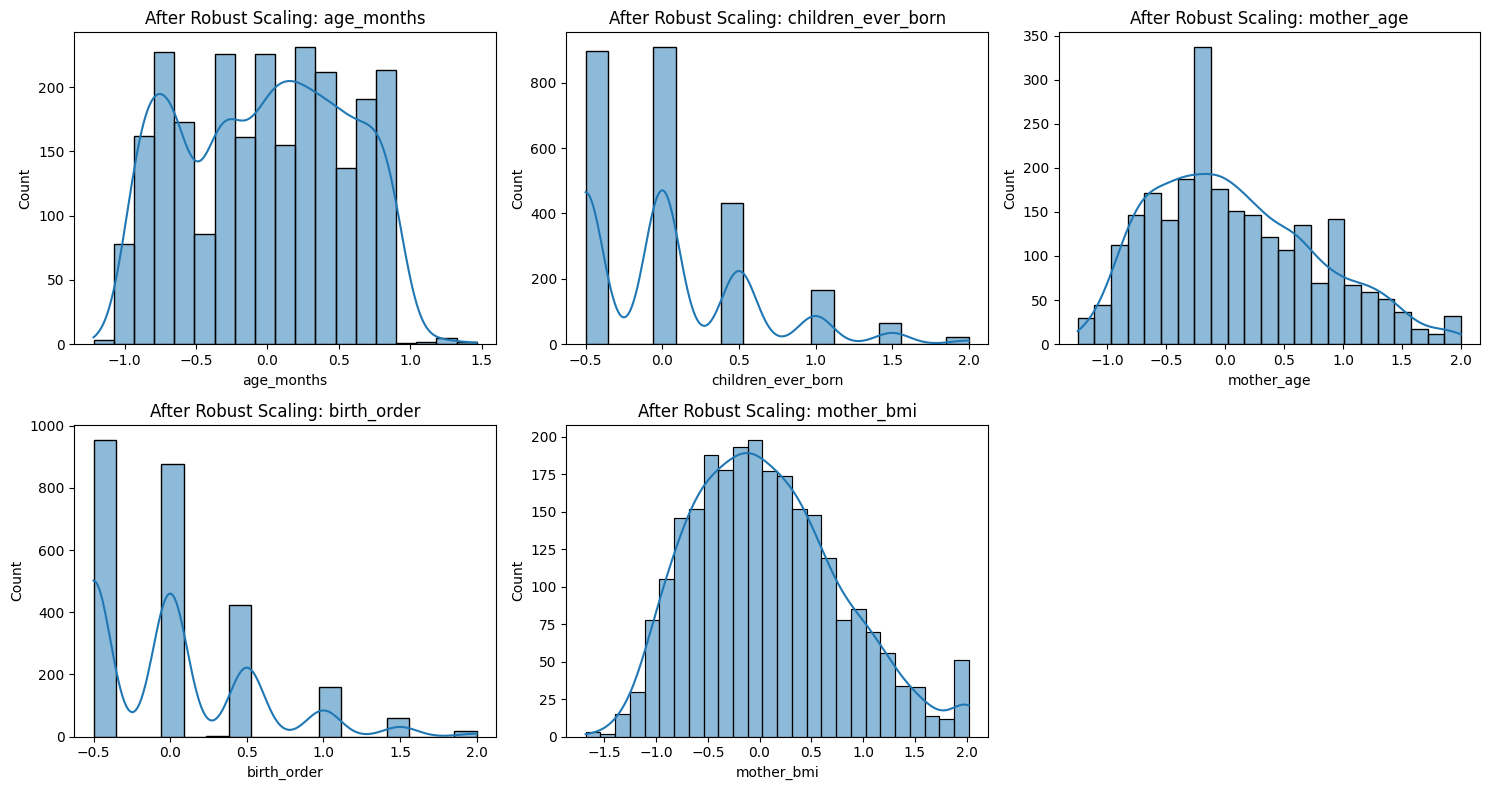

In [173]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
import pandas as pd

# Columns to scale
cols_to_scale = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi'
]

# Apply Robust Scaling
scaler = RobustScaler()
scaled_values = scaler.fit_transform(df[cols_to_scale])

scaled_df = pd.DataFrame(
    scaled_values,
    columns=cols_to_scale,
    index=df.index
)

# Plot distributions after scaling
plt.figure(figsize=(15, 8))
for i, col in enumerate(cols_to_scale):
    plt.subplot(2, 3, i + 1)
    sns.histplot(scaled_df[col], kde=True)
    plt.title(f"After Robust Scaling: {col}")

plt.tight_layout()
plt.show()


# class imbalance checking

In [174]:
# Class counts
stunted_counts = df['stunted'].value_counts()

# Class percentages
stunted_percent = df['stunted'].value_counts(normalize=True) * 100

print("Class Counts:")
print(stunted_counts)

print("\nClass Percentages (%):")
print(stunted_percent.round(2))


Class Counts:
stunted
0    1908
1     583
Name: count, dtype: int64

Class Percentages (%):
stunted
0    76.6
1    23.4
Name: proportion, dtype: float64


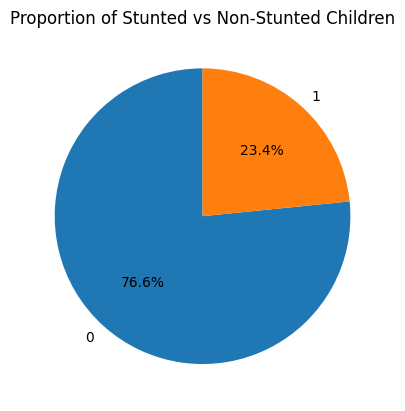

In [175]:
df['stunted'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.ylabel('')
plt.title('Proportion of Stunted vs Non-Stunted Children')
plt.show()



# Train Test Split (80% train, 20% test)

In [176]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Target
y = df["stunted"].astype(int)

# Drop non-predictor columns
drop_cols = ["stunted", "haz", "sample_weight", "wt", "child_line"]
X = df.drop(columns=drop_cols, errors="ignore")

# Make data safe before split
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Save master split indices for later feature-selection blocks
train_idx = X_train.index
test_idx = X_test.index

# Sanity checks
print("Final feature count:", X.shape[1])
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Verify removal
print("haz in X?", "haz" in X.columns)
print("weight in X?", any(col in X.columns for col in ["sample_weight", "wt"]))
print("child_line in X?", "child_line" in X.columns)

# Check saved indices
print("train_idx length:", len(train_idx))
print("test_idx length:", len(test_idx))

Final feature count: 19
Train shape: (1992, 19)
Test shape: (499, 19)
haz in X? False
weight in X? False
child_line in X? False
train_idx length: 1992
test_idx length: 499


Before SMOTE (Training Set Only):
stunted
0    1526
1     466
Name: count, dtype: int64

Percentage before SMOTE:
stunted
0    76.61
1    23.39
Name: proportion, dtype: float64

After SMOTE (Training Set Only):
stunted
0    1526
1    1526
Name: count, dtype: int64

Percentage after SMOTE:
stunted
0    50.0
1    50.0
Name: proportion, dtype: float64


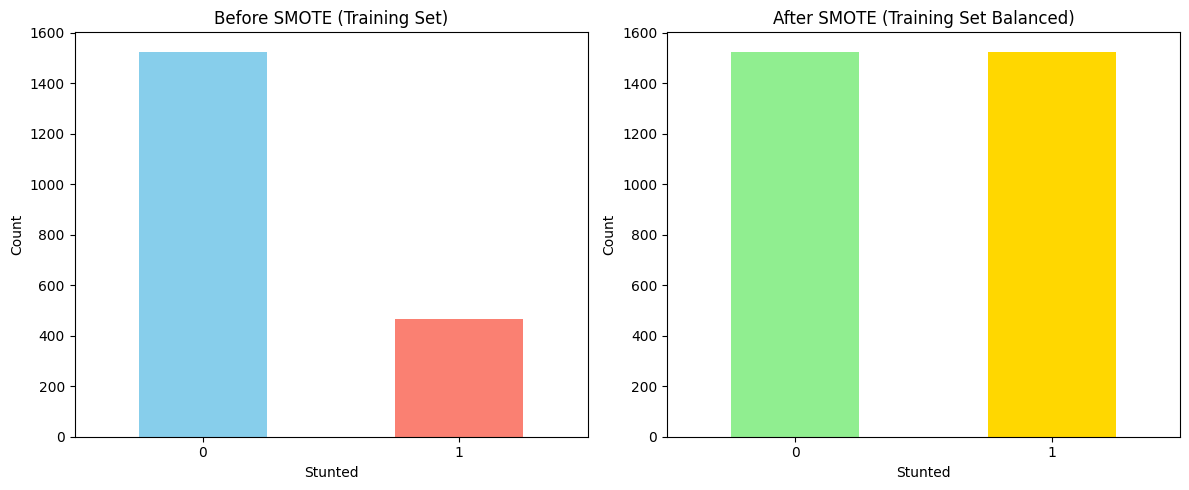


Shapes after SMOTE:
X_train shape: (3052, 19)
X_test shape : (499, 19)
y_train shape: (3052,)
y_test shape : (499,)


In [177]:
import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# Keep original column names so later code does not break
if isinstance(X_train, pd.DataFrame):
    train_columns = X_train.columns
    X_train_smote = X_train.apply(pd.to_numeric, errors='coerce').fillna(0).copy()
else:
    X_train_smote = pd.DataFrame(np.nan_to_num(X_train))
    train_columns = X_train_smote.columns

# Keep X_test safe too, but DO NOT apply SMOTE on test set
if isinstance(X_test, pd.DataFrame):
    X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0).copy()
else:
    X_test = pd.DataFrame(np.nan_to_num(X_test))

# Make sure targets are clean
y_train_smote = pd.Series(y_train).astype(int).reset_index(drop=True)
y_test = pd.Series(y_test).astype(int).reset_index(drop=True)

print("Before SMOTE (Training Set Only):")
print(y_train_smote.value_counts().sort_index())
print("\nPercentage before SMOTE:")
print((y_train_smote.value_counts(normalize=True).sort_index() * 100).round(2))

# ==============================================
# APPLY SMOTE ONLY ON TRAINING SET
# ==============================================
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_smote, y_train_smote)

# Convert back to DataFrame/Series so later code continues to work
X_train = pd.DataFrame(X_train_resampled, columns=train_columns)
y_train = pd.Series(y_train_resampled, name='stunted')

print("\n" + "=" * 50)
print("After SMOTE (Training Set Only):")
print(y_train.value_counts().sort_index())
print("\nPercentage after SMOTE:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

# ==============================================
# VISUALIZATION
# ==============================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before SMOTE
y_train_smote.value_counts().sort_index().plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    ax=axes[0]
)
axes[0].set_title('Before SMOTE (Training Set)')
axes[0].set_xlabel('Stunted')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['0', '1'], rotation=0)

# After SMOTE
y_train.value_counts().sort_index().plot(
    kind='bar',
    color=['lightgreen', 'gold'],
    ax=axes[1]
)
axes[1].set_title('After SMOTE (Training Set Balanced)')
axes[1].set_xlabel('Stunted')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.show()

# ==============================================
# FINAL SHAPE CHECK
# ==============================================
print("\nShapes after SMOTE:")
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

# feature list

In [178]:
for i, feat in enumerate(X.columns, start=1):
    print(f"{i}. {feat}")

1. age_months
2. mother_edu
3. birth_order
4. mother_occ
5. children_ever_born
6. father_edu
7. division
8. mother_age
9. mother_bmi
10. father_occ_clean
11. skilled_birth
12. toilet_improved
13. delivery_place_3cat
14. has_tv_clean
15. has_electricity_clean
16. reads_newspaper_clean
17. small_at_birth
18. wants_more_children
19. wealth_index_clean


# 1. Filter Method: SelectKBest with Mutual Information

This selects top features based on mutual information (measures dependency between features and target).
It's fast and doesn't overfit, but ignores feature interactions.

# 2. Wrapper Method: Recursive Feature Elimination (RFE) with LogisticRegression
This recursively removes least important features using a model (here, LogisticRegression for multiclass). More accurate but slower.

# 3.Stepwise Backward Feature Selection Code

# 4.Boruta Algorithm

# 5.Grey Wolf Optimizer (GWO)  Feature Selection

Works well for complex datasets,
 Handles non-linear relationships,
 Avoids local minima,
 Good balance between exploration & exploitation,

In [179]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [180]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE

# Use existing X and y
X_gwo = X.copy()
y_gwo = y.copy()

n_features = X_gwo.shape[1]

# Use master split indices saved from the main split cell
X_train = X_gwo.loc[train_idx].copy()
X_test = X_gwo.loc[test_idx].copy()
y_train = y_gwo.loc[train_idx].copy()
y_test = y_gwo.loc[test_idx].copy()

# Make safe numeric if needed
X_train = X_train.apply(pd.to_numeric, errors='coerce').fillna(0)
X_test = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Apply SMOTE right after split (training data only)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("After SMOTE:")
print("X_train shape:", X_train.shape)
print("y_train class counts:")
print(pd.Series(y_train).value_counts())

# Convert to numpy (for slicing)
X_train_np = X_train.values
X_test_np = X_test.values

# GWO Parameters
n_wolves = 10
max_iter = 20
a_max = 2
a_min = 0

# Fitness function
def fitness_function(subset, X_train, X_test, y_train, y_test):
    if np.sum(subset) == 0:
        return 0
    try:
        selected_train = X_train[:, subset == 1]
        selected_test = X_test[:, subset == 1]

        model = CatBoostClassifier(iterations=50, verbose=0, random_state=42)
        model.fit(selected_train, y_train)

        y_pred = model.predict(selected_test)
        return accuracy_score(y_test, y_pred)

    except Exception as e:
        print(f"Fitness error: {e}")
        return 0

# Initialize population
population = np.random.randint(0, 2, (n_wolves, n_features))

# Initialize best wolves
alpha_pos = np.copy(population[0])
beta_pos = np.copy(population[1])
delta_pos = np.copy(population[2])
alpha_score = 0
beta_score = 0
delta_score = 0

# GWO Loop
for iter in range(max_iter):
    a = a_max - (a_max - a_min) * (iter / max_iter)

    for i in range(n_wolves):
        fitness = fitness_function(population[i], X_train_np, X_test_np, y_train, y_test)

        if fitness > alpha_score:
            alpha_score = fitness
            alpha_pos = np.copy(population[i])
        elif fitness > beta_score:
            beta_score = fitness
            beta_pos = np.copy(population[i])
        elif fitness > delta_score:
            delta_score = fitness
            delta_pos = np.copy(population[i])

    for i in range(n_wolves):
        for j in range(n_features):
            r1, r2 = np.random.rand(), np.random.rand()
            A1 = 2 * a * r1 - a
            C1 = 2 * r2
            D_alpha = abs(C1 * alpha_pos[j] - population[i][j])
            X1 = alpha_pos[j] - A1 * D_alpha

            r1, r2 = np.random.rand(), np.random.rand()
            A2 = 2 * a * r1 - a
            C2 = 2 * r2
            D_beta = abs(C2 * beta_pos[j] - population[i][j])
            X2 = beta_pos[j] - A2 * D_beta

            r1, r2 = np.random.rand(), np.random.rand()
            A3 = 2 * a * r1 - a
            C3 = 2 * r2
            D_delta = abs(C3 * delta_pos[j] - population[i][j])
            X3 = delta_pos[j] - A3 * D_delta

            new_pos = (X1 + X2 + X3) / 3
            population[i][j] = 1 if 1 / (1 + np.exp(-10 * (new_pos - 0.5))) > 0.5 else 0

    print(f"Iter {iter+1}: Best Score = {alpha_score:.4f}")

# Results
selected_indices = np.where(alpha_pos == 1)[0]
selected_features = X_gwo.columns[selected_indices].tolist()

print("Selected features:", selected_features)
print("Best accuracy:", alpha_score)

After SMOTE:
X_train shape: (3052, 19)
y_train class counts:
stunted
0    1526
1    1526
Name: count, dtype: int64
Iter 1: Best Score = 0.7315
Iter 2: Best Score = 0.7315
Iter 3: Best Score = 0.7315
Iter 4: Best Score = 0.7315
Iter 5: Best Score = 0.7315
Iter 6: Best Score = 0.7415
Iter 7: Best Score = 0.7415
Iter 8: Best Score = 0.7415
Iter 9: Best Score = 0.7415
Iter 10: Best Score = 0.7575
Iter 11: Best Score = 0.7575
Iter 12: Best Score = 0.7575
Iter 13: Best Score = 0.7575
Iter 14: Best Score = 0.7575
Iter 15: Best Score = 0.7575
Iter 16: Best Score = 0.7575
Iter 17: Best Score = 0.7575
Iter 18: Best Score = 0.7575
Iter 19: Best Score = 0.7575
Iter 20: Best Score = 0.7575
Selected features: ['birth_order', 'small_at_birth', 'wants_more_children']
Best accuracy: 0.7575150300601202


# 6.snake optimization

# Result of feature selection methods

In [181]:
selected_features = [
    "age_months",
    "birth_order",
    "mother_occ",
    "father_edu",
    "division",
    "mother_age",
    "delivery_place_3cat",
    "has_electricity_clean",
    "reads_newspaper_clean",
    "wants_more_children",
    "wealth_index_clean"
]

X_train = X_train[selected_features].copy()
X_test = X_test[selected_features].copy()

# Now heading to model fit step.

In [182]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME'),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

In [183]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, accuracy_score
)
import numpy as np
import pandas as pd

# Scale for ALL models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== 7 MODELS ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# ========== TRAIN & EVALUATE ALL 7 ==========
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"TRAINING: {name}")
    print(f"{'='*50}")

    try:
        # Use scaled data for ALL models
        X_fit, X_pred = X_train_scaled, X_test_scaled

        model.fit(X_fit, y_train)
        y_pred = model.predict(X_pred)

        if hasattr(model, 'predict_proba'):
            y_prob = model.predict_proba(X_pred)[:, 1]
        else:
            y_prob = model.decision_function(X_pred)

        train_acc = accuracy_score(y_train, model.predict(X_fit)) * 100
        test_acc = accuracy_score(y_test, y_pred) * 100

        print("Train Accuracy (%):", round(train_acc, 2))
        print("Test Accuracy (%):", round(test_acc, 2))

        # Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        print("TN {}".format(cm[0, 0]))
        print("FP {}".format(cm[0, 1]))
        print("FN {}".format(cm[1, 0]))
        print("TP {}".format(cm[1, 1]))

        print("Accuracy rate {:.2f}".format((cm[0, 0] + cm[1, 1]) / np.sum(cm) * 100))
        print("Misclassification rate {:.2f}".format((cm[0, 1] + cm[1, 0]) / np.sum(cm) * 100))

        # Metrics
        print("Precision:", precision_score(y_test, y_pred))
        print("Recall:", recall_score(y_test, y_pred))
        print("F1-score:", f1_score(y_test, y_pred))
        print("ROC-AUC:", roc_auc_score(y_test, y_prob))

        # Store results
        results.append({
            'Model': name,
            'Train_Acc': train_acc,
            'Test_Acc': test_acc,
            'F1': f1_score(y_test, y_pred),
            'ROC_AUC': roc_auc_score(y_test, y_prob),
            'Overfit_Gap': (train_acc - test_acc) / 100
        })

        print("-" * 50)

    except Exception as e:
        print(f"❌ ERROR in {name}: {str(e)}")
        results.append({'Model': name, 'Error': str(e)})

# ========== SUMMARY TABLE ==========
results_df = pd.DataFrame(results).sort_values('Test_Acc', ascending=False)
print("\n🏆 FINAL RANKING (Test Accuracy):")
print("=" * 60)
print(results_df.round(3).to_string(index=False))


TRAINING: Logistic Regression
Train Accuracy (%): 68.71
Test Accuracy (%): 66.13
TN 269
FP 113
FN 56
TP 61
Accuracy rate 66.13
Misclassification rate 33.87
Precision: 0.3505747126436782
Recall: 0.5213675213675214
F1-score: 0.41924398625429554
ROC-AUC: 0.6543160155725603
--------------------------------------------------

TRAINING: K-Nearest Neighbors
Train Accuracy (%): 80.57
Test Accuracy (%): 64.53
TN 262
FP 120
FN 57
TP 60
Accuracy rate 64.53
Misclassification rate 35.47
Precision: 0.3333333333333333
Recall: 0.5128205128205128
F1-score: 0.40404040404040403
ROC-AUC: 0.6403432228039558
--------------------------------------------------

TRAINING: Decision Tree
Train Accuracy (%): 71.92
Test Accuracy (%): 70.34
TN 294
FP 88
FN 60
TP 57
Accuracy rate 70.34
Misclassification rate 29.66
Precision: 0.3931034482758621
Recall: 0.48717948717948717
F1-score: 0.4351145038167939
ROC-AUC: 0.6636237526289882
--------------------------------------------------

TRAINING: Gradient Boosting
Train Acc

# KNN

In [184]:
# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [185]:
print("Train Accuracy (%):", knn.score(X_train, y_train) * 100)
print("Test Accuracy (%):", knn.score(X_test, y_test) * 100)

Train Accuracy (%): 81.91349934469201
Test Accuracy (%): 62.32464929859719


In [186]:
import numpy as np
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# KNN Model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross-validation on training set
cv_scores = cross_val_score(knn, X_train, y_train, cv=5)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

KNN Accuracy: 0.6232

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.64      0.72       382
           1       0.33      0.58      0.42       117

    accuracy                           0.62       499
   macro avg       0.58      0.61      0.57       499
weighted avg       0.71      0.62      0.65       499

CV Scores: [0.69558101 0.74631751 0.73606557 0.7295082  0.72786885]
Mean CV Accuracy: 0.7271 (+/- 0.0341)


In [187]:
# ========== Import Libraries ==========
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ========== Scale ALL DATA ==========
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ========== Define Models ==========
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Naive Bayes': GaussianNB()
}

# ========== Train and Evaluate All Models ==========
results = []

print("=" * 80)
print("MODEL COMPARISON - ALL SCALED")
print("=" * 80)

for name, model in models.items():
    print(f"\nTraining {name}...")

    # ✅ ALL models use scaled data
    model.fit(X_train_scaled, y_train)

    train_acc = model.score(X_train_scaled, y_train) * 100
    test_acc = model.score(X_test_scaled, y_test) * 100
    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'Train Accuracy (%)': round(train_acc, 2),
        'Test Accuracy (%)': round(test_acc, 2),
        'Predictions': y_pred
    })

    print(f"  ✓ Train Accuracy: {train_acc:.2f}%")
    print(f"  ✓ Test Accuracy:  {test_acc:.2f}%")

# ========== Create Results DataFrame ==========
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print(results_df[['Model', 'Train Accuracy (%)', 'Test Accuracy (%)']].to_string(index=False))

# ========== Best Model ==========
best_model_name = results_df.iloc[0]['Model']
best_accuracy = results_df.iloc[0]['Test Accuracy (%)']

print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"   Test Accuracy: {best_accuracy:.2f}%")
print("=" * 80)

# ========== Detailed Evaluation for Best Model ==========
best_predictions = results_df.iloc[0]['Predictions']

print("\n" + "=" * 80)
print(f"DETAILED EVALUATION - {best_model_name}")
print("=" * 80)

print("\n📊 CONFUSION MATRIX:")
print(confusion_matrix(y_test, best_predictions))

print("\n📋 CLASSIFICATION REPORT:")
print(classification_report(y_test, best_predictions))

MODEL COMPARISON - ALL SCALED

Training Logistic Regression...
  ✓ Train Accuracy: 68.71%
  ✓ Test Accuracy:  66.13%

Training K-Nearest Neighbors...
  ✓ Train Accuracy: 80.57%
  ✓ Test Accuracy:  64.53%

Training Decision Tree...
  ✓ Train Accuracy: 100.00%
  ✓ Test Accuracy:  67.74%

Training Gradient Boosting...
  ✓ Train Accuracy: 83.06%
  ✓ Test Accuracy:  74.35%

Training AdaBoost...
  ✓ Train Accuracy: 76.87%
  ✓ Test Accuracy:  71.94%

Training SVM...
  ✓ Train Accuracy: 74.18%
  ✓ Test Accuracy:  68.54%

Training Naive Bayes...
  ✓ Train Accuracy: 69.30%
  ✓ Test Accuracy:  64.53%

SUMMARY TABLE
              Model  Train Accuracy (%)  Test Accuracy (%)
  Gradient Boosting               83.06              74.35
           AdaBoost               76.87              71.94
                SVM               74.18              68.54
      Decision Tree              100.00              67.74
Logistic Regression               68.71              66.13
K-Nearest Neighbors               

🎓 LEARNING CURVES FOR ALL MODELS
Computing learning curve for Decision Tree...

Decision Tree: Final Train-Val Gap = 5.20%
⚡ WARNING: Mild Overfitting
Decision Tree        | Train Acc: 0.799 | Val Acc: 0.747 | Test Acc: 0.760
Computing learning curve for AdaBoost...

AdaBoost: Final Train-Val Gap = 0.83%
✅ Good: No significant overfitting
AdaBoost             | Train Acc: 0.772 | Val Acc: 0.764 | Test Acc: 0.772
Computing learning curve for Gradient Boosting...

Gradient Boosting: Final Train-Val Gap = 5.47%
⚡ WARNING: Mild Overfitting
Gradient Boosting    | Train Acc: 0.812 | Val Acc: 0.757 | Test Acc: 0.758
Computing learning curve for Logistic Regression...

Logistic Regression: Final Train-Val Gap = 0.39%
✅ Good: No significant overfitting
Logistic Regression  | Train Acc: 0.768 | Val Acc: 0.764 | Test Acc: 0.766
Computing learning curve for SVM...

SVM: Final Train-Val Gap = 0.61%
✅ Good: No significant overfitting
SVM                  | Train Acc: 0.770 | Val Acc: 0.764 | Test Ac

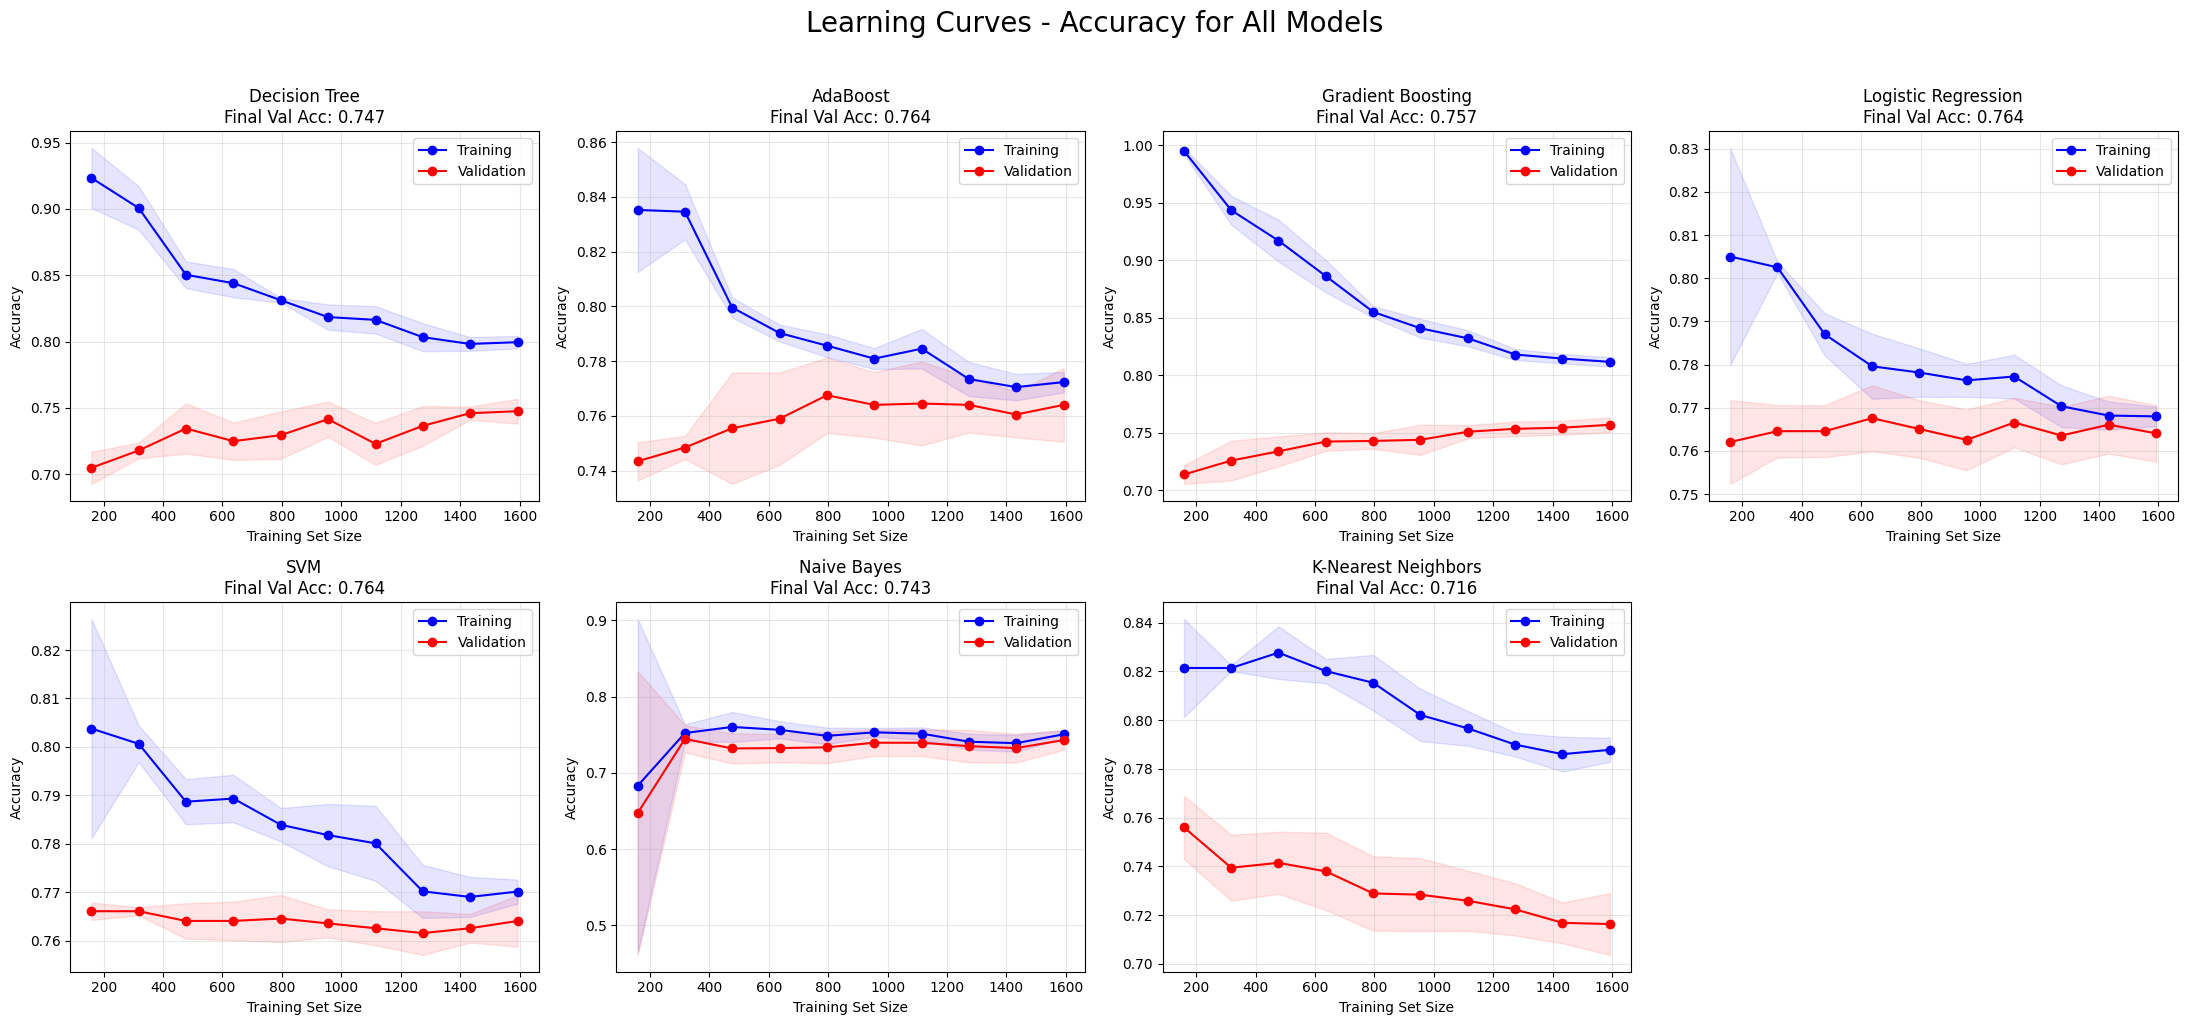


📊 FINAL PERFORMANCE SUMMARY
              Model  Test Accuracy  Test ROC  Train Accuracy
           AdaBoost         0.7715    0.6884          0.7701
                SVM         0.7675    0.6072          0.7676
Logistic Regression         0.7655    0.6733          0.7671
      Decision Tree         0.7595    0.6833          0.7897
  Gradient Boosting         0.7575    0.6749          0.8027
        Naive Bayes         0.7495    0.6442          0.7490
K-Nearest Neighbors         0.7335    0.6361          0.7892


In [188]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Your data (use selected_features)
X_selected = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

# Fix data types
def fix_data_types(X):
    X_fixed = X.copy()
    for col in X.columns:
        X_fixed[col] = pd.to_numeric(X_fixed[col], errors='coerce').fillna(0)
    return X_fixed

X_train_fixed = fix_data_types(X_train)
X_test_fixed = fix_data_types(X_test)

print("🎓 LEARNING CURVES FOR ALL MODELS")
print("="*60)

# Scale all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fixed)
X_test_scaled = scaler.transform(X_test_fixed)

# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# ==============================================
# LEARNING CURVES
# ==============================================
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

train_sizes = np.linspace(0.1, 1.0, 10)

for idx, (name, model) in enumerate(models.items()):
    print(f"Computing learning curve for {name}...")

    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    size_values, train_scores, val_scores = learning_curve(
        model, X_train_model, y_train,
        train_sizes=train_sizes,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)

    axes[idx].plot(size_values, train_mean, 'o-', color='blue', label='Training')
    axes[idx].fill_between(size_values, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
    axes[idx].plot(size_values, val_mean, 'o-', color='red', label='Validation')
    axes[idx].fill_between(size_values, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')
    axes[idx].set_title(f'{name}\nFinal Val Acc: {val_mean[-1]:.3f}')
    axes[idx].set_xlabel('Training Set Size')
    axes[idx].set_ylabel('Accuracy')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend()

    final_gap_pct = (train_mean[-1] - val_mean[-1]) * 100
    print(f"\n{name}: Final Train-Val Gap = {final_gap_pct:.2f}%")

    if final_gap_pct > 10:
        print("⚠️ WARNING: Possible Overfitting!")
    elif final_gap_pct > 5:
        print("⚡ WARNING: Mild Overfitting")
    else:
        print("✅ Good: No significant overfitting")

    model.fit(X_train_model, y_train)
    final_acc = accuracy_score(y_test, model.predict(X_test_model))
    print(f"{name:20} | Train Acc: {train_mean[-1]:.3f} | Val Acc: {val_mean[-1]:.3f} | Test Acc: {final_acc:.3f}")

# Remove the unused 8th subplot so only 7 plots remain
for j in range(len(models), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Learning Curves - Accuracy for All Models', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# SUMMARY TABLE
# ==============================================
results = []
for name, model in models.items():
    X_train_model = X_train_scaled
    X_test_model = X_test_scaled

    model.fit(X_train_model, y_train)
    y_pred = model.predict(X_test_model)

    results.append({
        'Model': name,
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test ROC': roc_auc_score(y_test, model.predict_proba(X_test_model)[:, 1]),
        'Train Accuracy': accuracy_score(y_train, model.predict(X_train_model))
    })

results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False)
print("\n📊 FINAL PERFORMANCE SUMMARY")
print("="*50)
print(results_df.round(4).to_string(index=False))

In [189]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# ==============================
# MODEL DICTIONARY
# ==============================
models_dict = {
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# ==============================
# OVERFITTING CHECK FUNCTION
# ==============================
def quick_overfit_check_classification(models_dict, X_train, X_test, y_train, y_test):
    results = []

    # Proper scaling: fit only on training data, then transform both
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    for name, model in models_dict.items():
        print(f"Training {name}...")

        # Fit model on scaled training data
        model.fit(X_train_scaled, y_train)

        # Predictions
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)

        # Accuracy
        train_acc = accuracy_score(y_train, train_pred)
        test_acc = accuracy_score(y_test, test_pred)
        gap = train_acc - test_acc

        # ROC-AUC (binary safe)
        auc_info = ""
        if hasattr(model, "predict_proba"):
            try:
                train_proba = model.predict_proba(X_train_scaled)[:, 1]
                test_proba = model.predict_proba(X_test_scaled)[:, 1]

                train_auc = roc_auc_score(y_train, train_proba)
                test_auc = roc_auc_score(y_test, test_proba)
                auc_gap = train_auc - test_auc

                auc_info = f" | AUC Gap: {auc_gap:.3f}"
            except:
                pass

        # Overfitting status
        if gap > 0.08:
            status = "🔴 OVERFITTING!"
        elif gap > 0.03:
            status = "🟡 Moderate"
        else:
            status = "🟢 Good"

        # Store results
        results.append({
            'Model': name,
            'Train Acc': round(train_acc, 3),
            'Test Acc': round(test_acc, 3),
            'Gap': round(gap, 3),
            'Status': status
        })

        print(f"{name:20} | Train: {train_acc:.3f} | Test: {test_acc:.3f} | Gap: {gap:.3f} {status}{auc_info}")

    # Summary table
    df_results = pd.DataFrame(results).sort_values('Test Acc', ascending=False)

    print("\n" + "="*70)
    print("📊 FINAL OVERFITTING SUMMARY")
    print("="*70)
    print(df_results.to_string(index=False))

    overfit_count = sum(df_results['Gap'] > 0.08)
    print(f"\n📊 SUMMARY: {overfit_count}/{len(models_dict)} models are OVERFITTING!")

    return df_results

# ==============================
# RUN CHECK ON YOUR DATA
# ==============================
results_df = quick_overfit_check_classification(
    models_dict, X_train, X_test, y_train, y_test
)

Training Decision Tree...
Decision Tree        | Train: 0.790 | Test: 0.760 | Gap: 0.030 🟡 Moderate | AUC Gap: 0.078
Training AdaBoost...
AdaBoost             | Train: 0.770 | Test: 0.772 | Gap: -0.001 🟢 Good | AUC Gap: -0.000
Training Gradient Boosting...
Gradient Boosting    | Train: 0.803 | Test: 0.758 | Gap: 0.045 🟡 Moderate | AUC Gap: 0.131
Training Logistic Regression...
Logistic Regression  | Train: 0.767 | Test: 0.766 | Gap: 0.002 🟢 Good | AUC Gap: -0.012
Training SVM...
SVM                  | Train: 0.768 | Test: 0.768 | Gap: 0.000 🟢 Good | AUC Gap: 0.210
Training Naive Bayes...
Naive Bayes          | Train: 0.749 | Test: 0.749 | Gap: -0.001 🟢 Good | AUC Gap: 0.004
Training K-Nearest Neighbors...
K-Nearest Neighbors  | Train: 0.789 | Test: 0.733 | Gap: 0.056 🟡 Moderate | AUC Gap: 0.165

📊 FINAL OVERFITTING SUMMARY
              Model  Train Acc  Test Acc    Gap     Status
           AdaBoost      0.770     0.772 -0.001     🟢 Good
                SVM      0.768     0.768  0.000

In [190]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score

# Scale once
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

results = []

for name, model in models_dict.items():
    print(f"Training {name}...")

    # Use scaled data for ALL models
    X_fit, X_eval = X_train_scaled, X_test_scaled

    # Fit model
    model.fit(X_fit, y_train)

    # Predict class
    y_pred = model.predict(X_eval)

    # Predict probability / score for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_eval)
    else:
        y_prob = None

    results.append({
        'Model': name,
        'Test Accuracy (%)': round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision (%)': round(precision_score(y_test, y_pred, zero_division=0) * 100, 2),
        'Recall (%)': round(recall_score(y_test, y_pred, zero_division=0) * 100, 2),
        'F1 Score (%)': round(f1_score(y_test, y_pred, zero_division=0) * 100, 2),
        'ROC-AUC (%)': round(roc_auc_score(y_test, y_prob) * 100, 2) if y_prob is not None else None
    })

results_df = pd.DataFrame(results)

print("\n📊 SIMPLE EVALUATION TABLE (Percentage)")
print(results_df.to_string(index=False))

Training Decision Tree...
Training AdaBoost...
Training Gradient Boosting...
Training Logistic Regression...
Training SVM...
Training Naive Bayes...
Training K-Nearest Neighbors...

📊 SIMPLE EVALUATION TABLE (Percentage)
              Model  Test Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC (%)
      Decision Tree              75.95          47.17       21.37         29.41        68.33
           AdaBoost              77.15          66.67        5.13          9.52        68.84
  Gradient Boosting              75.75          42.86       10.26         16.55        67.49
Logistic Regression              76.55          50.00        5.13          9.30        67.33
                SVM              76.75         100.00        0.85          1.69        60.72
        Naive Bayes              74.95          43.55       23.08         30.17        64.42
K-Nearest Neighbors              73.35          36.21       17.95         24.00        63.61


# Gradient boosting - 76.7%, 100%, 60.7% but 0.85%,1.6%